Total files: 205
Files with gaps: 0
Files with overlap: 0


C:\Users\raulm\AppData\Local\Temp\ipykernel_7828\142708969.py:55: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(times, tr.data, "-", linewidth=0.7)


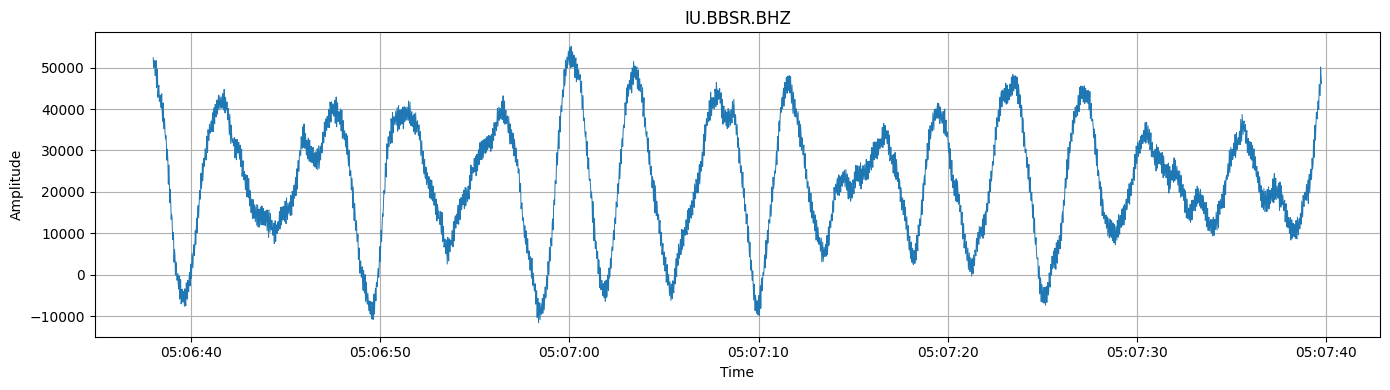

In [26]:
import os
from obspy import read
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = r"C:\Users\raulm\Downloads\ai-devvnew\out\waveform.win\2026\03\10"

mseed_files = []

for root, dirs, files in os.walk(DATA_FOLDER):
    for f in files:
        if f.endswith(".mseed"):
            mseed_files.append(os.path.join(root, f))

results = []

for file in sorted(mseed_files):

    try:
        st = read(file)
        st.merge(method=1)

        gaps = st.get_gaps()

        gap_count = len(gaps)
        overlap_count = sum(1 for g in gaps if g[6] < 0)

        tr = st[0]

        results.append({
            "file": file,
            "starttime": tr.stats.starttime.datetime,
            "endtime": tr.stats.endtime.datetime,
            "gap_count": gap_count,
            "overlap_count": overlap_count
        })

    except Exception as e:
        print("error reading:", file, e)

df = pd.DataFrame(results)

print("Total files:", len(df))
print("Files with gaps:", (df.gap_count > 0).sum())
print("Files with overlap:", (df.overlap_count > 0).sum())

# -------- Timeline Plot (NO SAMPLING) --------
import matplotlib.pyplot as plt

tr = st[0]

times = tr.times("matplotlib")   # ini membuat sumbu x = waktu

plt.figure(figsize=(14,4))
plt.plot_date(times, tr.data, "-", linewidth=0.7)

plt.title(f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\raulm\AppData\Local\Temp\ipykernel_7828\3203932540.py:43: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(times, tr.data, "-", linewidth=0.7)


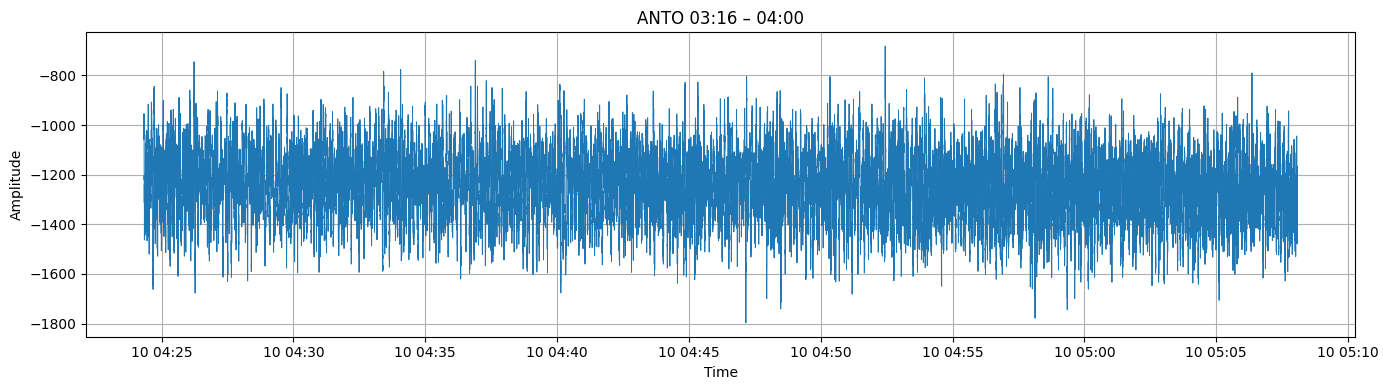

In [27]:
import os
from obspy import read
import matplotlib.pyplot as plt

DATA_FOLDER = r"C:\Users\raulm\Downloads\ai-devvnew\out\waveform.win\2026\03\10"

st = None

for root, dirs, files in os.walk(DATA_FOLDER):
    for f in files:
        if f.endswith(".mseed"):
            path = os.path.join(root, f)
            if st is None:
                st = read(path)
            else:
                st += read(path)

st.merge(method=1, fill_value=None)

import os
from obspy import read
import matplotlib.pyplot as plt

DATA_FOLDER = r"C:\Users\raulm\Downloads\ai-devvnew\out\waveform.win\2026\03\10"

st = None

for root, dirs, files in os.walk(DATA_FOLDER):
    for f in files:
        if f.endswith(".mseed"):
            path = os.path.join(root, f)
            if st is None:
                st = read(path)
            else:
                st += read(path)

st.merge(method=1, fill_value=None)
tr = st[0]

times = tr.times("matplotlib")

plt.figure(figsize=(14,4))
plt.plot_date(times, tr.data, "-", linewidth=0.7)

plt.title("ANTO 03:16 – 04:00")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()
plt.show()

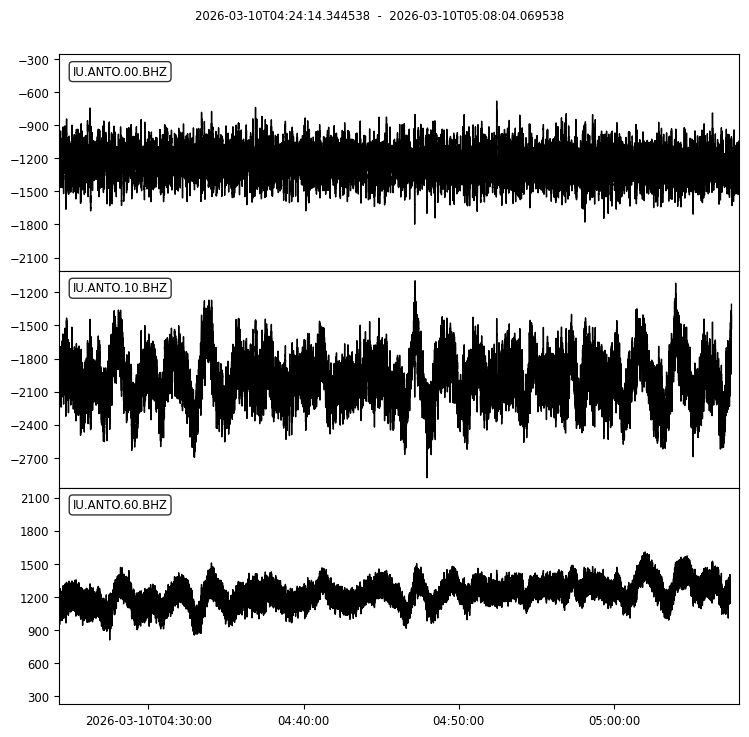

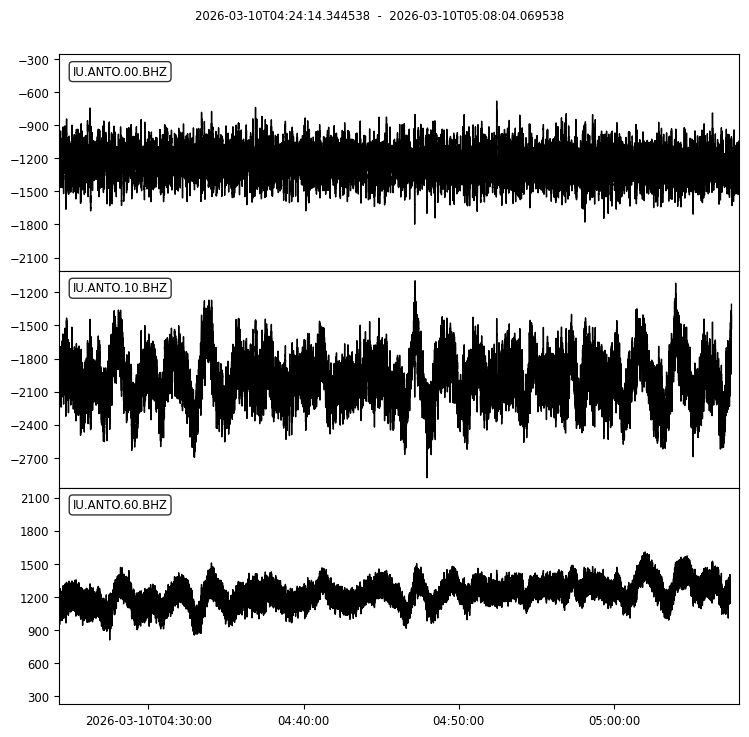

In [28]:
from obspy import read
import glob

files = glob.glob("out/waveform.win/2026/03/10/IU.ANTO*.mseed")

st = None
for f in files:
    if st is None:
        st = read(f)
    else:
        st += read(f)

st.merge()
st.plot()